In [ ]:
from google.colab import files
uploaded = files.upload()

Saving fetal_health.csv to fetal_health.csv


In [ ]:
# ---------------------------------------------------------
# 1) Setup & Imports
# ---------------------------------------------------------
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import (
    train_test_split, StratifiedKFold,
    cross_val_score, learning_curve,
    RandomizedSearchCV
)
from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.metrics import (
    accuracy_score, recall_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay,
    roc_auc_score, average_precision_score
)
from sklearn.calibration import calibration_curve
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE

from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.neural_network import MLPClassifier

from scipy.stats import wilcoxon
from sklearn.utils import resample
import shap

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (10,6)
CLASS_NAMES = ["Normal", "Suspect", "Pathological"]

In [ ]:
# ---------------------------------------------------------
# 2) Load + Clean (MANDATORY)
# ---------------------------------------------------------
df = pd.read_csv("fetal_health.csv")

print(df.shape)
print(df.isnull().sum())
print("Duplicates:", df.duplicated().sum())

# Remove duplicates (must)
df = df.drop_duplicates().reset_index(drop=True)

print("After duplicate removal:", df.shape)
print(df["fetal_health"].value_counts(normalize=True))
display(df.head())

(2126, 22)
baseline value                                            0
accelerations                                             0
fetal_movement                                            0
uterine_contractions                                      0
light_decelerations                                       0
severe_decelerations                                      0
prolongued_decelerations                                  0
abnormal_short_term_variability                           0
mean_value_of_short_term_variability                      0
percentage_of_time_with_abnormal_long_term_variability    0
mean_value_of_long_term_variability                       0
histogram_width                                           0
histogram_min                                             0
histogram_max                                             0
histogram_number_of_peaks                                 0
histogram_number_of_zeroes                                0
histogram_mode               

,baseline value,accelerations,fetal_movement,uterine_contractions,light_decelerations,severe_decelerations,prolongued_decelerations,abnormal_short_term_variability,mean_value_of_short_term_variability,percentage_of_time_with_abnormal_long_term_variability,...,histogram_min,histogram_max,histogram_number_of_peaks,histogram_number_of_zeroes,histogram_mode,histogram_mean,histogram_median,histogram_variance,histogram_tendency,fetal_health
0,120.0,0.000,0.0,0.000,0.000,0.0,0.0,73.0,0.5,43.0,...,62.0,126.0,2.0,0.0,120.0,137.0,121.0,73.0,1.0,2.0
1,132.0,0.006,0.0,0.006,0.003,0.0,0.0,17.0,2.1,0.0,...,68.0,198.0,6.0,1.0,141.0,136.0,140.0,12.0,0.0,1.0
2,133.0,0.003,0.0,0.008,0.003,0.0,0.0,16.0,2.1,0.0,...,68.0,198.0,5.0,1.0,141.0,135.0,138.0,13.0,0.0,1.0
3,134.0,0.003,0.0,0.008,0.003,0.0,0.0,16.0,2.4,0.0,...,53.0,170.0,11.0,0.0,137.0,134.0,137.0,13.0,1.0,1.0
4,132.0,0.007,0.0,0.008,0.000,0.0,0.0,16.0,2.4,0.0,...,53.0,170.0,9.0,0.0,137.0,136.0,138.0,11.0,1.0,1.0


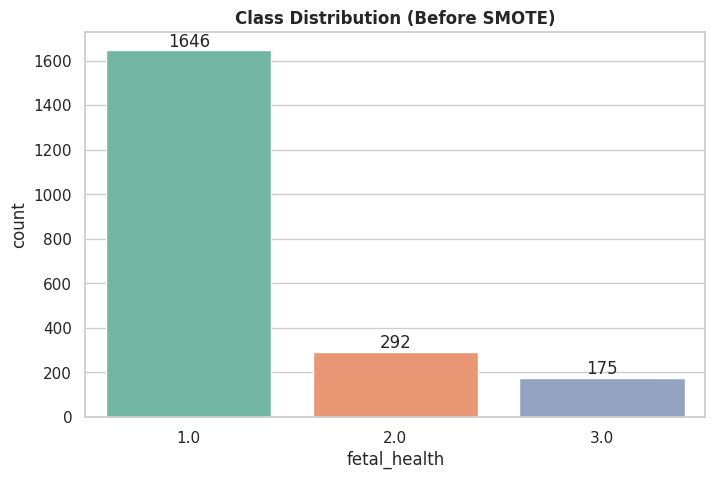

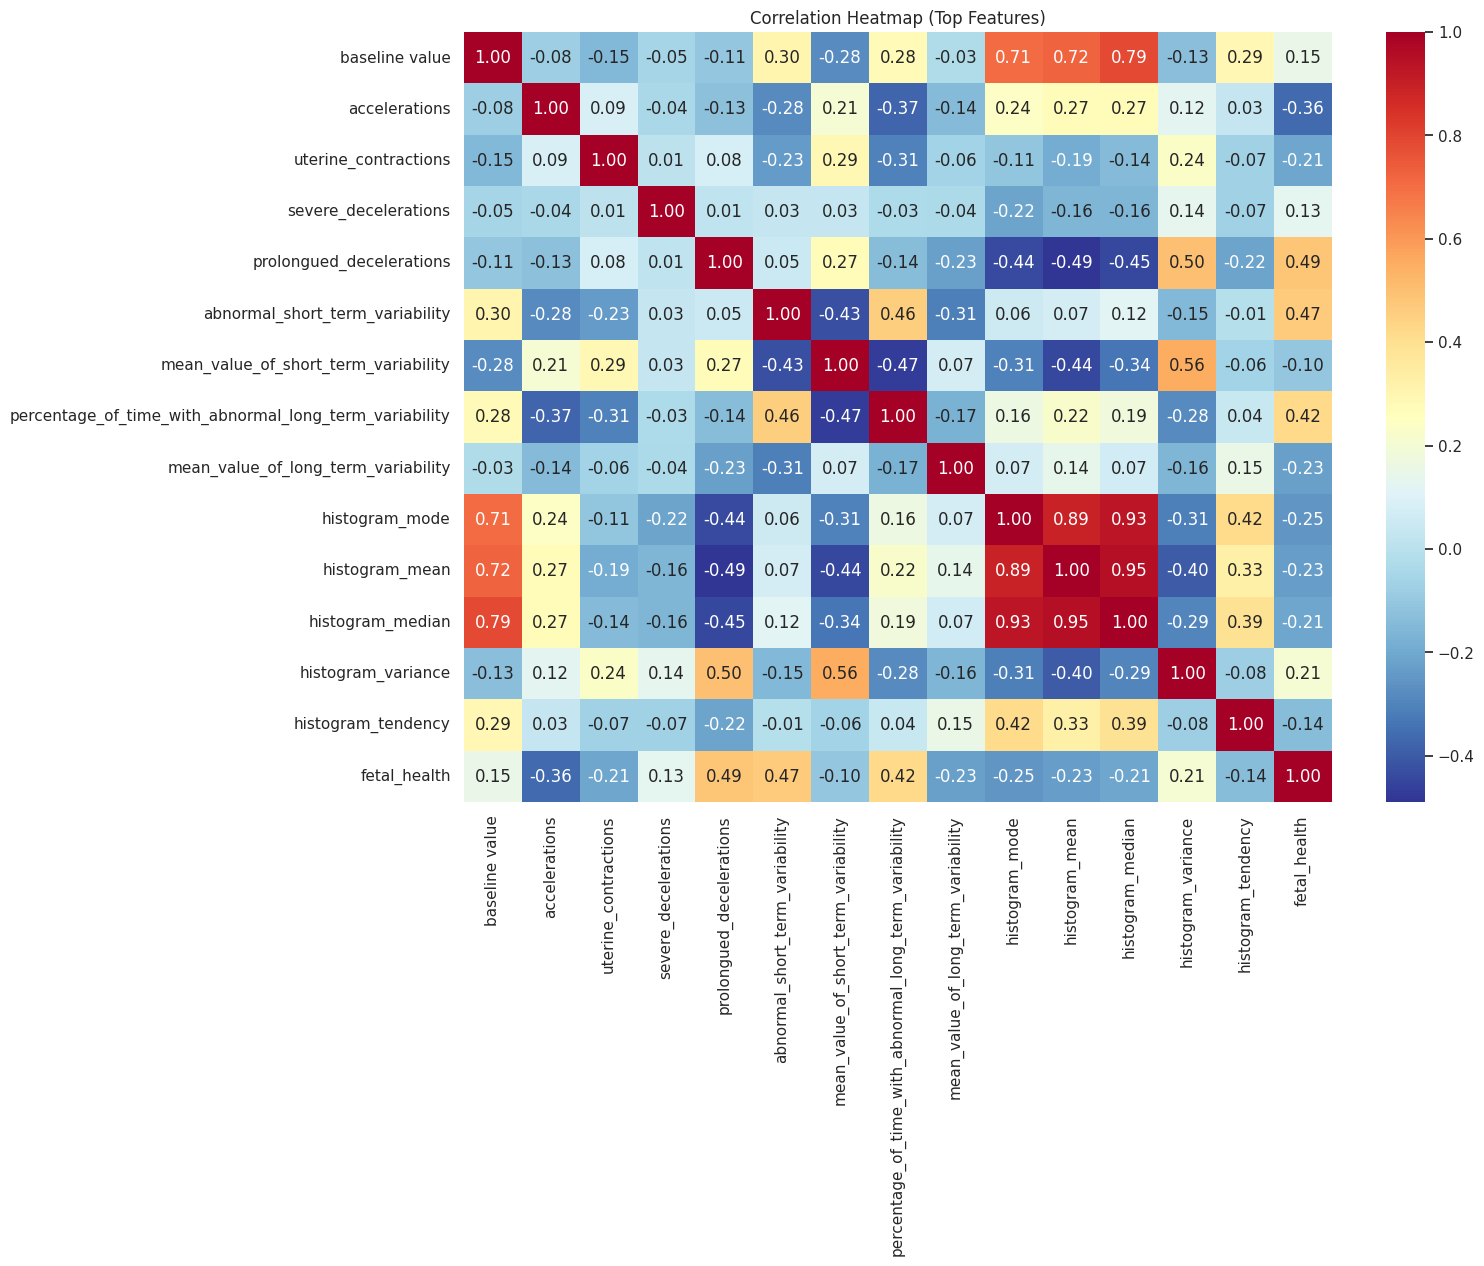

In [ ]:
# ---------------------------------------------------------
# 3) EDA (Class Distribution + Correlation)
# ---------------------------------------------------------
plt.figure(figsize=(8,5))
ax = sns.countplot(x="fetal_health", data=df, palette="Set2")
plt.title("Class Distribution (Before SMOTE)", fontweight="bold")
for p in ax.patches:
    ax.annotate(f"{int(p.get_height())}",
                (p.get_x()+p.get_width()/2, p.get_height()),
                ha="center", va="bottom")
plt.show()

plt.figure(figsize=(14,10))
corr = df.corr()
top_feats = corr.index[abs(corr["fetal_health"]) > 0.1]
sns.heatmap(df[top_feats].corr(), annot=True, cmap="RdYlBu_r", fmt=".2f")
plt.title("Correlation Heatmap (Top Features)")
plt.show()

In [ ]:
# ---------------------------------------------------------
# 4) Stratified Split + Pipeline (Leakage‑Free)
# ---------------------------------------------------------
X = df.drop("fetal_health", axis=1)
y = df["fetal_health"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

def build_pipeline(model):
    return ImbPipeline([
        ("scaler", StandardScaler()),
        ("smote", SMOTE(random_state=42)),
        ("clf", model)
    ])

cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

In [ ]:
# ---------------------------------------------------------
# 5) Ablation Study — SMOTE Impact (Must‑Add)
# ---------------------------------------------------------
from sklearn.pipeline import Pipeline as SkPipeline

ablation_results = []
for name, clf in [
    ("Decision Tree", DecisionTreeClassifier(random_state=42)),
    ("Random Forest", RandomForestClassifier(random_state=42))
]:
    # Without SMOTE
    pipe_no = SkPipeline([
        ("scaler", StandardScaler()),
        ("clf", clf)
    ])
    score_no = cross_val_score(
        pipe_no, X_train, y_train, cv=cv, scoring="recall_macro"
    ).mean()

    # With SMOTE
    pipe_yes = build_pipeline(clf)
    score_yes = cross_val_score(
        pipe_yes, X_train, y_train, cv=cv, scoring="recall_macro"
    ).mean()

    ablation_results.append({
        "Model": name,
        "Without SMOTE": round(score_no,4),
        "With SMOTE": round(score_yes,4),
        "Improvement": round(score_yes-score_no,4)
    })

ablation_df = pd.DataFrame(ablation_results)
display(ablation_df)
ablation_df.to_excel("ablation_smote.xlsx", index=False)

,Model,Without SMOTE,With SMOTE,Improvement
0,Decision Tree,0.8541,0.8501,-0.0041
1,Random Forest,0.8568,0.8956,0.0388


In [20]:
# ---------------------------------------------------------
# 6) CV Comparative Table — FINAL FIXED VERSION
# ---------------------------------------------------------
from sklearn.model_selection import GridSearchCV
from sklearn.base import clone

models = {
    "KNN": KNeighborsClassifier(),
    "LogReg": LogisticRegression(
        max_iter=2000, solver="lbfgs",
        multi_class="multinomial"
    ),
    "DT": DecisionTreeClassifier(random_state=42),
    "NB": GaussianNB(),
    "RF": RandomForestClassifier(
        random_state=42, class_weight="balanced"
    ),
    "MLP": MLPClassifier(
        max_iter=1000,
        early_stopping=True,
        random_state=42
    )
}

param_grids = {
    "KNN": {"clf__n_neighbors": [3, 5, 7, 9]},
    "LogReg": {"clf__C": [0.1, 1, 10]},
    "DT": {"clf__max_depth": [5, 10, None]},
    "RF": {
        "clf__n_estimators": [100, 200, 300],
        "clf__max_depth": [5, 10, None]
    },
    "MLP": {
        "clf__hidden_layer_sizes": [
            (50,), (100,), (100, 50)
        ]
    }
}

best_estimators = {}
best_params = {}
cv_results = []

for name, clf in models.items():
    pipeline = build_pipeline(clf)

    if name in param_grids:
        search = GridSearchCV(
            pipeline,
            param_grids[name],
            cv=cv,
            scoring="recall_macro",
            n_jobs=-1
        )
        search.fit(X_train, y_train)
        best_estimators[name] = search.best_estimator_
        best_params[name] = search.best_params_
        best_score = search.best_score_

    else:
        # NB — no tuning, safe clone fit
        scores = cross_val_score(
            pipeline, X_train, y_train,
            cv=cv, scoring="recall_macro"
        )
        fresh_pipe = clone(pipeline)
        fresh_pipe.fit(X_train, y_train)
        best_estimators[name] = fresh_pipe
        best_params[name] = {}
        best_score = scores.mean()

    cv_results.append({
        "Model": name,
        "CV_Macro_Recall": round(best_score, 4)
    })
    print(f"✅ {name}: {best_score:.4f}")

cv_df = pd.DataFrame(cv_results).sort_values(
    by="CV_Macro_Recall", ascending=False
)
display(cv_df)
cv_df.to_excel("CV_Comparative_Table.xlsx", index=False)

✅ KNN: 0.8593
✅ LogReg: 0.8479
✅ DT: 0.8620
✅ NB: 0.7564
✅ RF: 0.9014
✅ MLP: 0.8653


,Model,CV_Macro_Recall
4,RF,0.9014
5,MLP,0.8653
2,DT,0.8620
0,KNN,0.8593
1,LogReg,0.8479
3,NB,0.7564


In [21]:
# ---------------------------------------------------------
# 7) Voting Ensemble (Fixed, Unfitted Estimators)
# ---------------------------------------------------------
lr_params = {k.replace("clf__", ""): v for k,v in best_params["LogReg"].items()}
dt_params = {k.replace("clf__", ""): v for k,v in best_params["DT"].items()}
rf_params = {k.replace("clf__", ""): v for k,v in best_params["RF"].items()}

best_lr = LogisticRegression(max_iter=2000, solver="lbfgs", multi_class="multinomial", **lr_params)
best_dt = DecisionTreeClassifier(random_state=42, **dt_params)
best_rf = RandomForestClassifier(random_state=42, class_weight="balanced", **rf_params)

voting = VotingClassifier(
    estimators=[("lr", best_lr), ("dt", best_dt), ("rf", best_rf)],
    voting="soft"
)

voting_pipeline = build_pipeline(voting)

voting_scores = cross_val_score(
    voting_pipeline, X_train, y_train, cv=cv, scoring="recall_macro"
)
voting_pipeline.fit(X_train, y_train)

best_estimators["Voting"] = voting_pipeline

cv_df = pd.concat([cv_df, pd.DataFrame([{
    "Model": "Voting", "CV_Macro_Recall": round(voting_scores.mean(),4)
}])]).sort_values(by="CV_Macro_Recall", ascending=False)

display(cv_df)
cv_df.to_excel("CV_Comparative_Table.xlsx", index=False)

,Model,CV_Macro_Recall
4,RF,0.9014
0,Voting,0.8842
5,MLP,0.8653
2,DT,0.8620
0,KNN,0.8593
1,LogReg,0.8479
3,NB,0.7564


In [23]:
# ---------------------------------------------------------
# 8) Test Set Evaluation (Descriptive Only)
# ---------------------------------------------------------
test_results = []
classes = [1.0, 2.0, 3.0]

for name, pipeline in best_estimators.items():
    y_pred = pipeline.predict(X_test)
    y_prob = pipeline.predict_proba(X_test) if hasattr(pipeline, "predict_proba") else None

    acc = accuracy_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred, average="macro")
    f1 = f1_score(y_test, y_pred, average="macro")

    y_test_bin = label_binarize(y_test, classes=classes)
    roc_auc = roc_auc_score(y_test, y_prob, multi_class="ovr", average="macro") if y_prob is not None else None
    pr_auc = average_precision_score(y_test_bin, y_prob, average="macro") if y_prob is not None else None

    per_class = recall_score(y_test, y_pred, average=None)

    test_results.append({
        "Model": name,
        "Accuracy": round(acc,4),
        "Macro Recall": round(recall,4),
        "Macro F1": round(f1,4),
        "ROC-AUC": round(roc_auc,4) if roc_auc is not None else "N/A",
        "PR-AUC": round(pr_auc,4) if pr_auc is not None else "N/A",
        "Normal Recall": round(per_class[0],4),
        "Suspect Recall": round(per_class[1],4),
        "Pathological Recall": round(per_class[2],4)
    })

test_df = pd.DataFrame(test_results).sort_values(by="Macro Recall", ascending=False)
display(test_df)
test_df.to_excel("Test_All_Models_Descriptive.xlsx", index=False)

,Model,Accuracy,Macro Recall,Macro F1,ROC-AUC,PR-AUC,Normal Recall,Suspect Recall,Pathological Recall
6,Voting,0.9338,0.8941,0.8950,0.9868,0.9468,0.9576,0.8103,0.9143
4,RF,0.9456,0.8887,0.9011,0.9875,0.9603,0.9818,0.7414,0.9429
2,DT,0.9196,0.8700,0.8720,0.8933,0.8086,0.9485,0.7759,0.8857
1,LogReg,0.8723,0.8470,0.7987,0.9639,0.8405,0.8848,0.8276,0.8286
0,KNN,0.8747,0.8433,0.8039,0.9345,0.7880,0.8909,0.8103,0.8286
5,MLP,0.8865,0.8076,0.7952,0.9744,0.8888,0.9273,0.7241,0.7714
3,NB,0.7329,0.7297,0.6353,0.8637,0.6690,0.7212,0.8966,0.5714


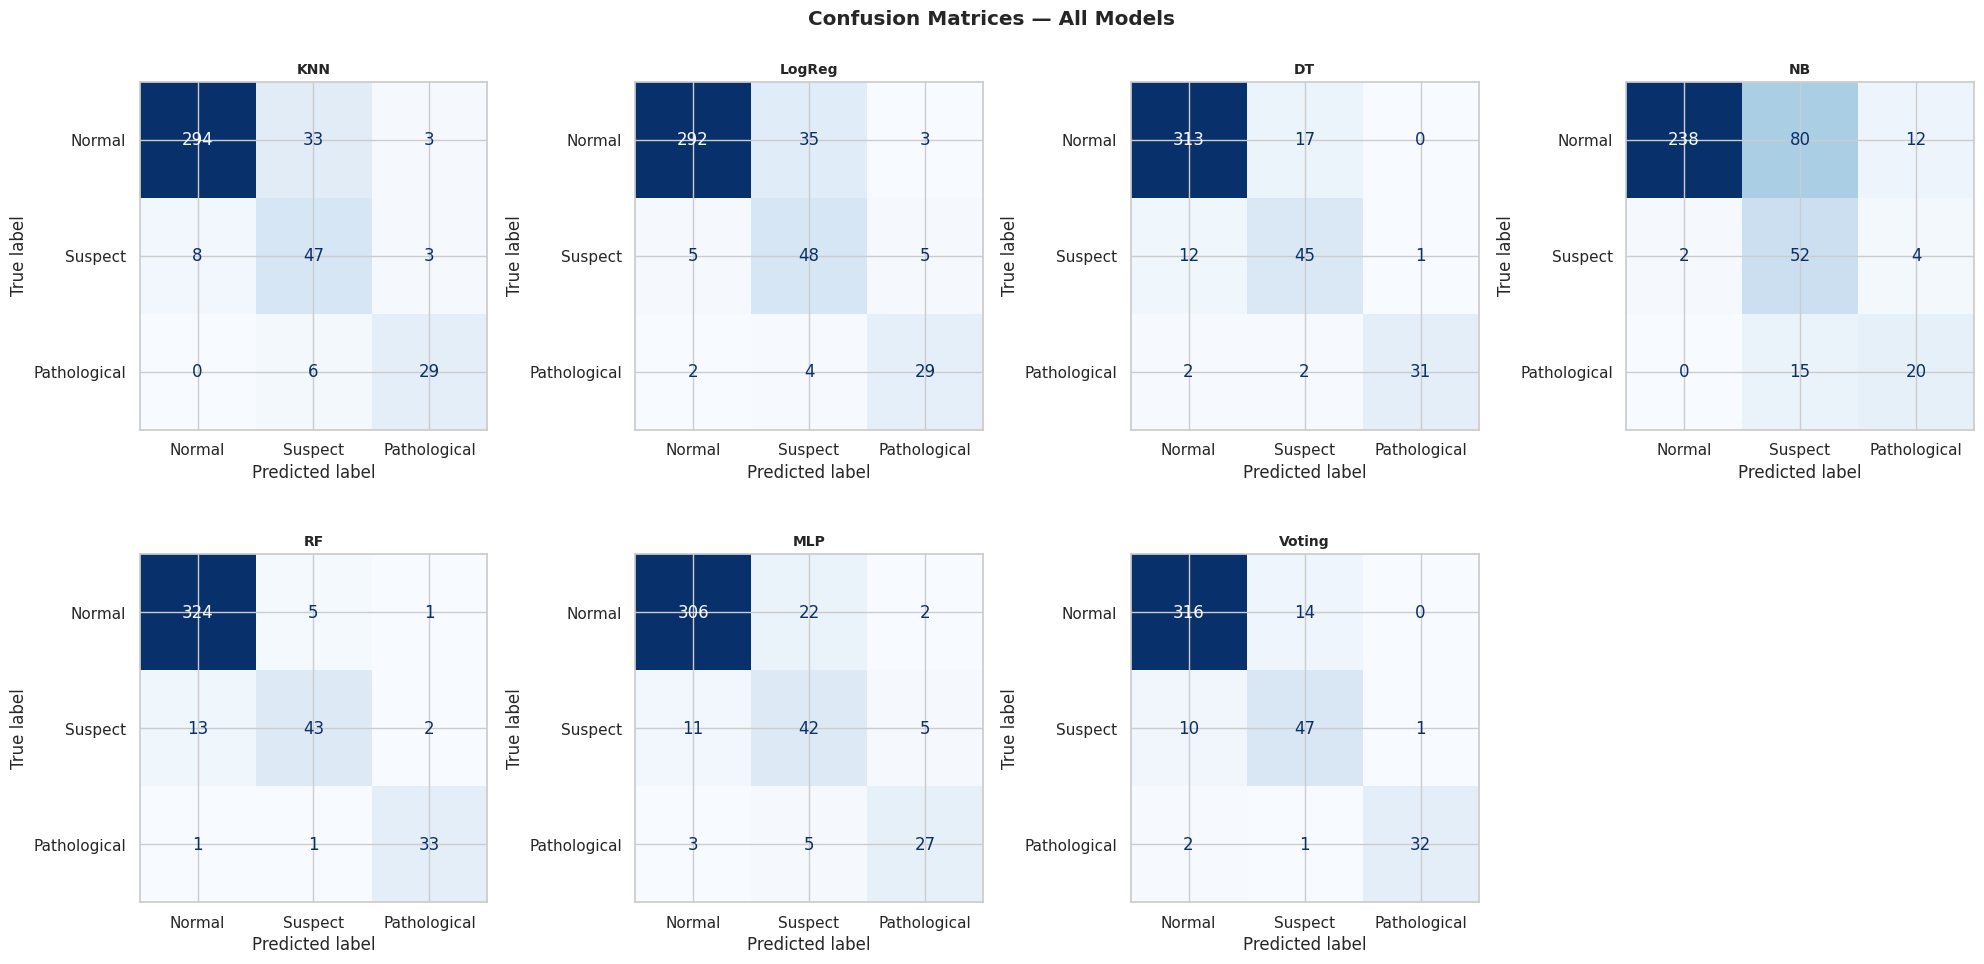

In [24]:
# ---------------------------------------------------------
# 9) Confusion Matrices (All Models)
# ---------------------------------------------------------
fig, axes = plt.subplots(2, 4, figsize=(20,10))
axes = axes.flatten()

for i, (name, pipeline) in enumerate(best_estimators.items()):
    y_pred = pipeline.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=CLASS_NAMES)
    disp.plot(ax=axes[i], colorbar=False, cmap="Blues")
    axes[i].set_title(name, fontweight="bold", fontsize=10)

if len(best_estimators) < 8:
    axes[-1].set_visible(False)

plt.suptitle("Confusion Matrices — All Models", fontweight="bold")
plt.tight_layout()
plt.savefig("fig_confusion_matrices.png", dpi=300, bbox_inches="tight")
plt.show()

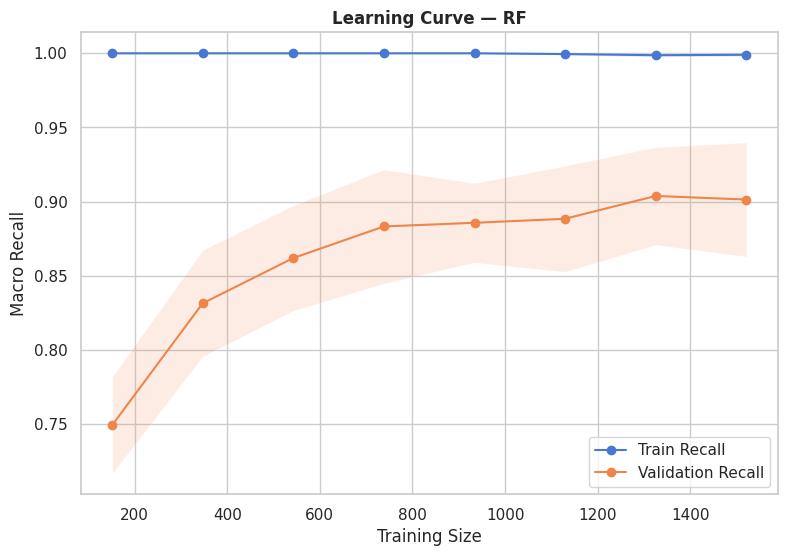

In [25]:
# ---------------------------------------------------------
# 10) Learning Curve (Best CV Model)
# ---------------------------------------------------------
best_model_name = cv_df.iloc[0]["Model"]
best_pipeline = best_estimators[best_model_name]

train_sizes, train_scores, val_scores = learning_curve(
    best_pipeline, X_train, y_train,
    cv=cv, scoring="recall_macro",
    train_sizes=np.linspace(0.1, 1.0, 8),
    n_jobs=-1
)

plt.figure(figsize=(9,6))
plt.plot(train_sizes, train_scores.mean(axis=1), "o-", label="Train Recall")
plt.plot(train_sizes, val_scores.mean(axis=1), "o-", label="Validation Recall")
plt.fill_between(train_sizes,
                 train_scores.mean(1)-train_scores.std(1),
                 train_scores.mean(1)+train_scores.std(1), alpha=0.15)
plt.fill_between(train_sizes,
                 val_scores.mean(1)-val_scores.std(1),
                 val_scores.mean(1)+val_scores.std(1), alpha=0.15)
plt.title(f"Learning Curve — {best_model_name}", fontweight="bold")
plt.xlabel("Training Size")
plt.ylabel("Macro Recall")
plt.legend()
plt.grid(True)
plt.savefig("fig_learning_curve.png", dpi=300, bbox_inches="tight")
plt.show()

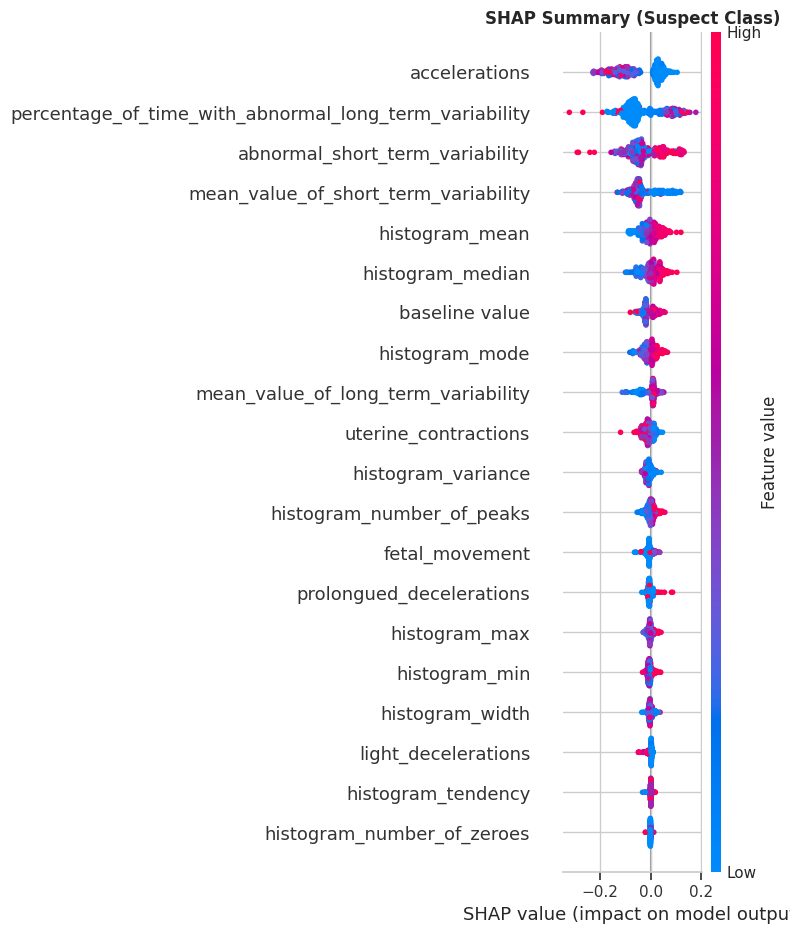

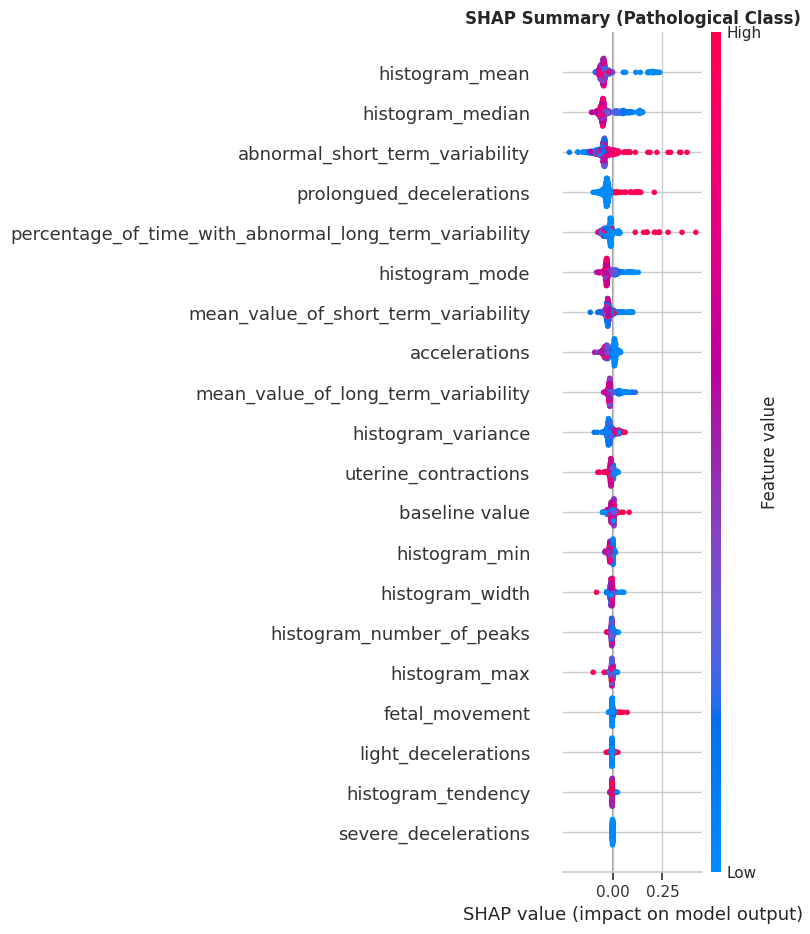

In [26]:
# ---------------------------------------------------------
# 11) SHAP (Tree Model Only)
# ---------------------------------------------------------
tree_models = ["RF", "DT", "Random Forest", "Decision Tree"]
shap_target = next((m for m in cv_df["Model"].tolist() if m in tree_models), None)

if shap_target:
    pipeline = best_estimators[shap_target]
    clf = pipeline.named_steps["clf"]
    X_test_scaled = pipeline.named_steps["scaler"].transform(X_test)

    explainer = shap.TreeExplainer(clf)
    shap_values = explainer.shap_values(X_test_scaled)

    for class_idx, class_name in [(1, "Suspect"), (2, "Pathological")]:
        shap_values_cls = shap_values[class_idx] if isinstance(shap_values, list) else shap_values[:, :, class_idx]
        plt.figure(figsize=(10,6))
        shap.summary_plot(shap_values_cls, X_test_scaled, feature_names=X.columns, show=False)
        plt.title(f"SHAP Summary ({class_name} Class)", fontweight="bold")
        plt.tight_layout()
        plt.savefig(f"fig_shap_{class_name.lower()}.png", dpi=300, bbox_inches="tight")
        plt.show()
else:
    print("No tree model available for SHAP.")

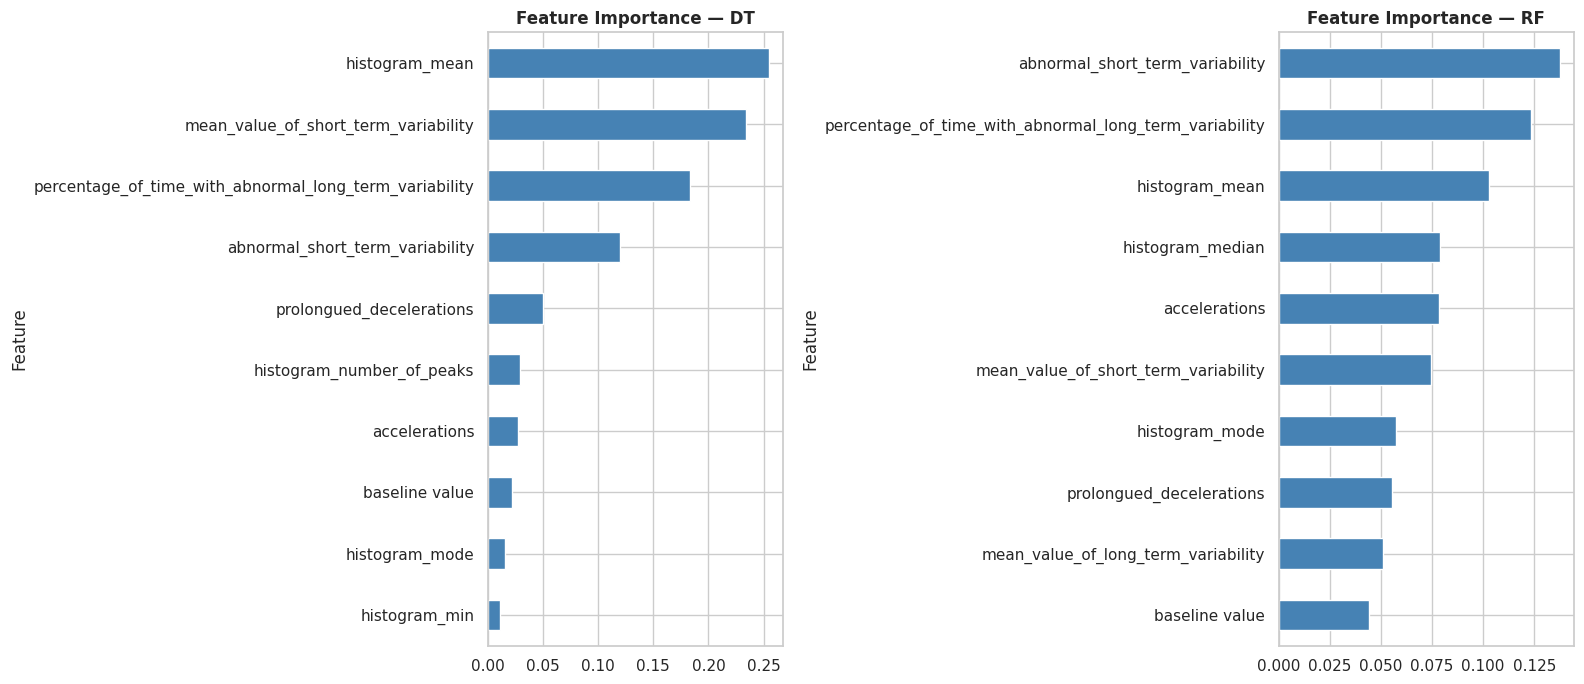

In [27]:
# ---------------------------------------------------------
# 11.5) Feature Importance (DT + RF)
# ---------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

for ax, model_name in zip(axes, ["DT", "RF"]):
    clf = best_estimators[model_name].named_steps["clf"]
    feat_df = pd.DataFrame({
        "Feature": X.columns,
        "Importance": clf.feature_importances_
    }).sort_values("Importance", ascending=True).tail(10)

    feat_df.plot(kind="barh", x="Feature", y="Importance",
                 ax=ax, legend=False, color="steelblue")
    ax.set_title(f"Feature Importance — {model_name}", fontweight="bold")

plt.tight_layout()
plt.savefig("fig_feature_importance.png", dpi=300, bbox_inches="tight")
plt.show()

Macro Recall CI (Test Descriptive): 0.8892752400555992 (np.float64(0.8399362878902041), np.float64(0.9354337102706787))


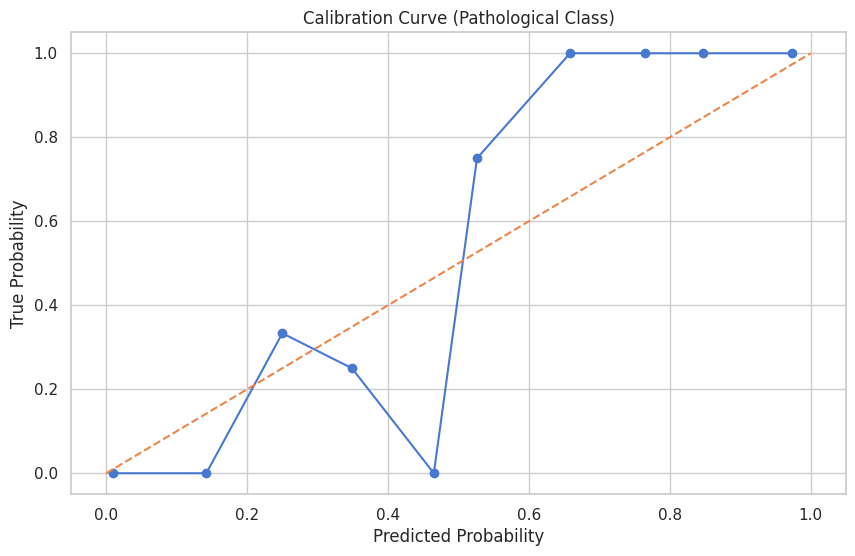

In [28]:
# ---------------------------------------------------------
# 12) Bootstrap CI + Calibration (Test Descriptive)
# ---------------------------------------------------------
def bootstrap_ci(y_true, y_pred, metric_func, n_boot=1000, alpha=0.95):
    scores = []
    for _ in range(n_boot):
        idx = resample(range(len(y_true)))
        scores.append(metric_func(np.array(y_true)[idx], np.array(y_pred)[idx]))
    lower = np.percentile(scores, (1-alpha)/2*100)
    upper = np.percentile(scores, (1+(alpha))/2*100)
    return np.mean(scores), (lower, upper)

pipeline = best_estimators[best_model_name]
pipeline.fit(X_train, y_train)
y_pred = pipeline.predict(X_test)

mean_recall, ci = bootstrap_ci(
    y_test, y_pred,
    lambda yt, yp: recall_score(yt, yp, average="macro")
)
print("Macro Recall CI (Test Descriptive):", mean_recall, ci)

# Calibration curve (Pathological Class)
y_prob = pipeline.predict_proba(X_test)
prob_true, prob_pred = calibration_curve((y_test==3).astype(int), y_prob[:,2], n_bins=10)
plt.plot(prob_pred, prob_true, marker="o")
plt.plot([0,1], [0,1], "--")
plt.title("Calibration Curve (Pathological Class)")
plt.xlabel("Predicted Probability")
plt.ylabel("True Probability")
plt.show()

In [29]:
# ---------------------------------------------------------
# 12B) CV Macro Recall ± 95% CI + Wilcoxon
# ---------------------------------------------------------
import numpy as np
import pandas as pd
from scipy import stats
from sklearn.model_selection import cross_val_score
from scipy.stats import wilcoxon

def mean_ci(scores, confidence=0.95):
    scores = np.array(scores)
    mean = scores.mean()
    sem = stats.sem(scores)
    h = sem * stats.t.ppf((1 + confidence) / 2, len(scores)-1)
    return mean, (mean-h, mean+h)

ci_rows = []
for name, model in best_estimators.items():
    scores = cross_val_score(model, X_train, y_train, cv=cv, scoring="recall_macro")
    mean, ci = mean_ci(scores)
    ci_rows.append({
        "Model": name,
        "CV_Macro_Recall": round(mean,4),
        "95%_CI": f"[{ci[0]:.4f}, {ci[1]:.4f}]"
    })

ci_df = pd.DataFrame(ci_rows).sort_values("CV_Macro_Recall", ascending=False)
display(ci_df)

best = ci_df.iloc[0]["Model"]
baselines = ci_df.iloc[1:3]["Model"].tolist()

best_scores = cross_val_score(best_estimators[best], X_train, y_train, cv=cv, scoring="recall_macro")

wilcoxon_rows = []
for base in baselines:
    base_scores = cross_val_score(best_estimators[base], X_train, y_train, cv=cv, scoring="recall_macro")
    stat, p = wilcoxon(best_scores, base_scores)
    wilcoxon_rows.append({"Best": best, "Baseline": base, "p_value": p})

wilcoxon_df = pd.DataFrame(wilcoxon_rows)
display(wilcoxon_df)

,Model,CV_Macro_Recall,95%_CI
4,RF,0.9014,"[0.8725, 0.9304]"
6,Voting,0.8842,"[0.8535, 0.9149]"
5,MLP,0.8653,"[0.8338, 0.8967]"
2,DT,0.8620,"[0.8282, 0.8958]"
0,KNN,0.8593,"[0.8181, 0.9005]"
1,LogReg,0.8479,"[0.8192, 0.8766]"
3,NB,0.7564,"[0.7300, 0.7828]"


,Best,Baseline,p_value
0,RF,Voting,0.130859
1,RF,MLP,0.009766
